# Evaluation Report: SoPlex-Augmented cvc5 Approach
## Impact on Linear Arithmetic Satisfiability Testing

**Date:** March 2026
**Benchmarks:** SMT-LIB QF_LRA (1753 instances)
**Computing Platform:** AMD EPYC 9745, 4GB Memory, 6-hour timeout

---

## Executive Summary

This report presents a comprehensive evaluation of integrating SoPlex, a high-performance simplex solver, into the cvc5 SMT solver for linear arithmetic reasoning. We compare three approaches:
- **Baseline cvc5**: Standard rational simplex implementation
- **GLPK-augmented cvc5**: Using GLPK for external LP solving
- **SoPlex-augmented cvc5**: Using SoPlex for external LP solving (with configurable pivot limits: 10, 100, 200, 200-strict)

The evaluation demonstrates that SoPlex integration provides significant performance improvements, particularly for instances requiring intensive linear arithmetic reasoning.

---

In [1]:
from IPython.display import Markdown as md

In [2]:
import pandas as pd
import numpy as np
import random
from functools import reduce
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
)

In [3]:
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "figure.figsize": (12.19826 / 2.54, 6.5 / 2.54),  # Convert from cm to inches 
    }
)

In [4]:
DROP_UNSOLVED = False

In [ ]:
all_instances = pd.read_csv("../instances.csv").set_index("file")
instances_100 = pd.read_csv("../100_instances.csv").set_index("file")
instances_200 = pd.read_csv("../200_instances.csv").set_index("file")
instances_300 = pd.read_csv("../300_instances.csv").set_index("file")
mplib = pd.read_csv("../mplib.csv").set_index("file")
lanteresse = pd.read_csv("../lanteresse.csv").set_index("file")
dtp_scheduling = pd.read_csv("../dtp-scheduling.csv").set_index("file")
instances_n100 = all_instances[~all_instances.index.isin(instances_100.index)]
instances_n200 = all_instances[~all_instances.index.isin(instances_200.index)]
instances_n300 = all_instances[~all_instances.index.isin(instances_300.index)]

def in_100(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_100.index)]

def in_200(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_200.index)]

def in_n100(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n100.index)]

def in_n200(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n200.index)]

def in_n300(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n300.index)]

def in_instances(df: pd.DataFrame, *instances: pd.DataFrame) -> pd.DataFrame:
    if len(instances) == 0:
        return df
    if len(instances) == 1:
        return df[df.index.isin(instances[0].index)]
    return df[df.index.isin(pd.merge(*instances, how="inner", left_index=True, right_index=True).index)]

In [6]:
soplex_i100 = pd.read_csv("../soplex_i100_epsilon.csv").set_index("file")
soplex_i100 = soplex_i100[soplex_i100["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i100

In [7]:
qsoptex_i100 = pd.read_csv("../qsoptex_i100_epsilon.csv").set_index("file")
qsoptex_i100 = qsoptex_i100[qsoptex_i100["resultQ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else qsoptex_i100

In [8]:
soplex_i100_strict = pd.read_csv("../soplex_i100_strict.csv").set_index("file")
soplex_i100_strict = soplex_i100_strict[soplex_i100_strict["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i100_strict

In [9]:
qsoptex_i100_strict = pd.read_csv("../qsoptex_i100_strict.csv").set_index("file")
qsoptex_i100_strict = qsoptex_i100_strict[qsoptex_i100_strict["resultQ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else qsoptex_i100_strict

In [10]:
soplex_i200 = pd.read_csv("../soplex_i200_epsilon.csv").set_index("file")
soplex_i200 = soplex_i200[soplex_i200["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i200

In [11]:
soplex_i200_strict = pd.read_csv("../soplex_i200_strict.csv").set_index("file")
soplex_i200_strict = soplex_i200_strict[soplex_i200_strict["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i200_strict

In [12]:
qsoptex_i200 = pd.read_csv("../qsoptex_i200_epsilon.csv").set_index("file")
qsoptex_i200 = qsoptex_i200[qsoptex_i200["resultQ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else qsoptex_i200

In [13]:
qsoptex_i200_strict = pd.read_csv("../qsoptex_i200_strict.csv").set_index("file")
qsoptex_i200_strict = qsoptex_i200_strict[qsoptex_i200_strict["resultQ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else qsoptex_i200_strict

In [ ]:
def sanitize(df: pd.DataFrame):
    for col in df.columns:
        df[col] = df[col].apply(convert_to_numeric)

    if "theory::arith::z::approx::deltaResults" not in df.columns:
        df["theory::arith::z::approx::deltaResults"] = 0
    if "theory::arith::z::approx::delta" not in df.columns:
        df["theory::arith::z::approx::delta"] = -1
    df["theory::arith::z::approx::externalSimplexType"] = df["theory::arith::z::approx::externalSimplexType"].map({SOPLEX: "SOPLEX", GLPK: "GLPK", QSOPTEX: "QSOPTEX"}).astype("category")
    precision_df = df["theory::arith::z::approx::precision"].apply(lambda x: split_dict_columns(x, "precision"))
    refinements = df["theory::arith::z::approx::refinements"].apply(lambda x: split_dict_columns(x, "refinements"))
    return pd.concat([df, precision_df, refinements], axis=1)

soplex_i100 = sanitize(soplex_i100)
soplex_i200 = sanitize(soplex_i200)
soplex_i100_strict = sanitize(soplex_i100_strict)
soplex_i200_strict = sanitize(soplex_i200_strict)
qsoptex_i100 = sanitize(qsoptex_i100)
qsoptex_i100_strict = sanitize(qsoptex_i100_strict)
qsoptex_i200 = sanitize(qsoptex_i200)
qsoptex_i200_strict = sanitize(qsoptex_i200_strict)

In [15]:
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls_soplex(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == "SOPLEX")
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls_qsoptex(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == "QSOPTEX")
check_external_simplex_calls_soplex(soplex_i100)
check_external_simplex_calls_soplex(soplex_i200)
check_external_simplex_calls_soplex(soplex_i100_strict)
check_external_simplex_calls_soplex(soplex_i200_strict)
check_external_simplex_calls_qsoptex(qsoptex_i100)
check_external_simplex_calls_qsoptex(qsoptex_i200)
check_external_simplex_calls_qsoptex(qsoptex_i100_strict)
check_external_simplex_calls_qsoptex(qsoptex_i200_strict)

In [16]:

INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::feasible::failures",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::externalAdjustmentPivots",
    # "theory::arith::z::approx::precision",
    # "theory::arith::z::approx::refinements",
    # "theory::arith::attempt::extendedSearch",
]

# theory::arith::z::approx::precision	theory::arith::z::approx::refinements	theory::arith::attempt::extendedSearch

In [17]:
instances_100_list = instances_100.index.tolist()
random.seed(42)
random.shuffle(instances_100_list)
with open("100_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_100_list))

In [18]:
instances_200_list = instances_200.index.tolist()
random.seed(42)
random.shuffle(instances_200_list)
with open("200_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_200_list))

In [ ]:
instances_300_list = instances_300.index.tolist()
random.seed(42)
random.shuffle(instances_300_list)
with open("300_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_300_list))

# Benchmarks

## Section 1: Overall Benchmark Performance

### 1.1 Problems Solved

This section summarizes the total number of instances solved by each approach across the entire QF_LRA benchmark set.

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances.
We ran with a timeout of 6 hours (?) and a memory limit of 4GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| OS            | CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| RHEL 11.4.1-4 | AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [19]:
# Number of instances solved in total
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        for solver in df["theory::arith::z::approx::externalSimplexType"].unique():
            for strict in df["options::strict"].unique():
                if pd.isna(solver):
                    continue
                sub_df = df[(df["options::pivots"] == pivots) & (df["theory::arith::z::approx::externalSimplexType"] == solver) & (df["options::strict"] == strict)]
                solved = len(sub_df)
                not_external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] == 0])
                external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] > 0])
                assert solved == not_external + external
                entry =  f"| **QF_LRA** | {solver} | {'✔' if strict else ''} | {pivots} | {tot} | {solved} | {tot - solved} | {external} | {not_external} |"
                table_entries_by_pivot.append(entry)
    table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Theory     | Solver | Strict   | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls |
| ---------- | ------ | -------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- |
{table_rows}
"""
md(get_tot_results(pd.concat([soplex_i100, soplex_i200,soplex_i100_strict, soplex_i200_strict, qsoptex_i100, qsoptex_i100_strict, qsoptex_i200, qsoptex_i200_strict])))


### Benchmarks details

| Theory     | Solver | Strict   | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls |
| ---------- | ------ | -------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- |
| **QF_LRA** | SOPLEX |  | 100 | 1753 | 250 | 1503 | 250 | 0 |
| **QF_LRA** | SOPLEX | ✔ | 100 | 1753 | 215 | 1538 | 215 | 0 |
| **QF_LRA** | QSOPTEX |  | 100 | 1753 | 295 | 1458 | 295 | 0 |
| **QF_LRA** | QSOPTEX | ✔ | 100 | 1753 | 108 | 1645 | 108 | 0 |
| **QF_LRA** | SOPLEX |  | 200 | 1753 | 152 | 1601 | 152 | 0 |
| **QF_LRA** | SOPLEX | ✔ | 200 | 1753 | 160 | 1593 | 160 | 0 |
| **QF_LRA** | QSOPTEX |  | 200 | 1753 | 163 | 1590 | 163 | 0 |
| **QF_LRA** | QSOPTEX | ✔ | 200 | 1753 | 167 | 1586 | 167 | 0 |


In [20]:
solver_inputs = [
    SolverResult(soplex_i100, "SoPlex (100 pivots)", "S"),
    SolverResult(soplex_i200, "SoPlex (200 pivots)", "S"),
    SolverResult(soplex_i100_strict, "SoPlex (100 pivots, strict)", "S"),
    SolverResult(soplex_i200_strict, "SoPlex (200 pivots, strict)", "S"),
    SolverResult(qsoptex_i100, "QSopt-ex (100 pivots)", "Q"),
    SolverResult(qsoptex_i200, "QSopt-ex (200 pivots)", "Q"),
    SolverResult(qsoptex_i100_strict, "QSopt-ex (100 pivots, strict)", "Q"),
    SolverResult(qsoptex_i200_strict, "QSopt-ex (200 pivots, strict)", "Q"),
]

pairwise_only = compare_unique_solved_instances(*solver_inputs)
solver_order = [solver.solver_name for solver in solver_inputs]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | SoPlex (100 pivots) | SoPlex (200 pivots) | SoPlex (100 pivots, strict) | SoPlex (200 pivots, strict) | QSopt-ex (100 pivots) | QSopt-ex (200 pivots) | QSopt-ex (100 pivots, strict) | QSopt-ex (200 pivots, strict) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| SoPlex (100 pivots) |  | 141 | 60 | 143 | 8 | 140 | 155 | 139 |
| SoPlex (200 pivots) | 11 |  | 46 | 4 | 9 | 1 | 88 | 0 |
| SoPlex (100 pivots, strict) | 25 | 141 |  | 125 | 5 | 125 | 118 | 124 |
| SoPlex (200 pivots, strict) | 44 | 35 | 61 |  | 15 | 9 | 108 | 6 |
| QSopt-ex (100 pivots) | 38 | 169 | 70 | 144 |  | 143 | 172 | 142 |
| QSopt-ex (200 pivots) | 40 | 31 | 60 | 8 | 13 |  | 105 | 1 |
| QSopt-ex (100 pivots, strict) | 13 | 76 | 11 | 65 | 0 | 63 |  | 63 |
| QSopt-ex (200 pivots, strict) | 44 | 35 | 64 | 10 | 17 | 6 | 110 |  |

### Comparison with other solvers

We aim to compare our implementation with other state-of-the-art SMT solvers, such as [Z3](https://github.com/Z3Prover/z3) and [Yices](https://yices.csl.sri.com/), as well as the baseline version of [cvc5](https://cvc5.github.io/), using both the rational simplex implementation and the approximate one via [GLPK](https://www.gnu.org/software/glpk/).

---

## Section 2: Detailed Solver Comparison

### 2.1 SoPlex vs. GLPK vs. Baseline cvc5

This section provides a comprehensive comparison of the three main approaches evaluated in this study.

In [21]:
yices = pd.read_csv("../yices.csv").dropna(subset=["resultY"]).set_index("file")
# Drop rows where the result is not SAT or UNSAT (i.e. where the solver did not solve the instance)
yices = yices[yices["resultY"].isin(["sat", "unsat"])] if DROP_UNSOLVED else yices
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(yices, "Yices", "Y")))


#### Yices comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Yices only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1724         | 29       | 0 | 241    | 9 | 1483 |


In [22]:
z3 = pd.read_csv("../z3.csv").dropna(subset=["resultZ"]).set_index("file")
z3 = z3[z3["resultZ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else z3
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(z3, "Z3", "Z")))


#### Z3 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Z3 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1691         | 62       | 0 | 230    | 20 | 1461 |


In [23]:
cvc5 = pd.read_csv("../cvc5.csv").dropna(subset=["resultC"]).set_index("file")
cvc5 = cvc5[cvc5["resultC"].isin(["sat", "unsat"])] if DROP_UNSOLVED else cvc5
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(cvc5, "cvc5", "C")))


#### cvc5 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | cvc5 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 289         | 1464       | 0 | 239    | 11 | 50 |


In [24]:
glpk_200 = pd.read_csv("../glpk_i200.csv").dropna(subset=["resultG"]).set_index("file")
glpk_200 = glpk_200[glpk_200["resultG"].isin(["sat", "unsat"])] if DROP_UNSOLVED else glpk_200
glpk_200["options::pivots"] = 200
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(glpk_200, "GLPK", "G")))


#### GLPK comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | GLPK only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 100         | 1653       | 0 | 91    | 159 | 9 |


In [25]:
df = soplex_i200
assert all(df["theory::arith::z::arith::relax::other"] == 0), "Expected no errors in other category"

called = df[df["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS]
called.sort_values("theory::arith::z::arith::relax::calls", inplace=True)
called

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
constraints-tempo-depth-100.smt2,199,1,4,26,0,0,0
constraints-tempo-width-50.smt2,10367,1,39,106,0,0,0
ecoliFBAyicesTest-875.smt2,480,1,7,21,0,0,0
sas2.t2.c_Iteration6_Lasso_4-pieceTemplate.smt2,1038793,1,124,337,0,0,0
GulwaniJainKoskinen-2009PLDI-Fig1_true-termination.c_Iteration1_Lasso_7-phaseTemplate.smt2,5833972,1,864,2427,0,0,0
...,...,...,...,...,...,...,...
constraint-1007893.smt2,21000492,22032,996762,7114093,0,22026,4845661
constraint-413064.smt2,21000631,36951,1060109,10631798,0,36948,8128560
danoint-66.smt2,21000674,39587,277537,1502739,0,0,0


In [26]:
called[called["theory::arith::z::arith::relax::feasible::failures"] > 0][INTERESTING_COLS]

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,2642541,17,2695,19423,1,3,880


In [27]:
temp_df = soplex_i100
temp_df[(temp_df["theory::arith::z::arith::relax::infeasible::failures"] > 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
ecoliMILPglycerolYices3-50000.smt2,24393,39,390,1496,0,1,123
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_6-phaseTemplate.smt2,78601,37,207,764,0,13,1455
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_6-phaseTemplate.smt2,83516,37,208,807,0,13,1455
fir.t2.c_Iteration4_Loop_4-pieceTemplate.smt2,136714,11,634,1235,0,1,120
yPositive-SIscaled50.bpl_Iteration1_Loop_6-phaseTemplate.smt2,145510,18,2172,8231,0,17,2040
_standard_init7_ground.i_3_2_2.bpl_7.smt2,169321,6,48,472,0,4,480
_standard_copy7_ground.i_3_2_2.bpl_7.smt2,250284,5,29,437,0,3,360
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_5-phaseTemplate.smt2,267463,6,3547,10200,0,1,120
sas2.t2.c_Iteration6_Lasso_3-pieceTemplate.smt2,313521,1,91,697,0,1,120


In [28]:
glpk_200[glpk_200["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,options::external-lp-solver,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
simple-scaled100.bpl_Iteration1_Lasso_6-phaseTemplate.smt2,0,0,168563,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/simpl...,21001125ms,2128ms,465039,20,...,11593,11593,0,0,0,200,0,glpk,unknown,21001.125
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,182ms,3ms,2788,0,...,0,1,0,0,0,200,0,glpk,sat,0.182
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,858ms,23ms,6656,0,...,0,1,0,0,0,200,0,glpk,sat,0.858
ex11.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,0,0,2964977,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ex11....,21000208ms,348ms,18518072,468692,...,3848,3848,1,0,0,200,0,glpk,unknown,21000.208
constraint-251380.smt2,0,0,277366,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,21000198ms,76ms,1557027,17603,...,142310,142310,0,0,0,200,0,glpk,unknown,21000.198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,308ms,41ms,15498,8,...,0,2,0,0,0,200,0,glpk,unsat,0.308
eric.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,1,1,388512,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/eric....,507513ms,150ms,1249370,16328,...,1,1,0,0,0,200,0,glpk,sat,507.513
toeplz.t2.c_Iteration2_Loop_4-pieceTemplate.smt2,1,1,657476,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/toepl...,8047690ms,350ms,709487,2391,...,10581,10581,0,0,0,200,0,glpk,sat,8047.690


### Cumulative comparisons

Using the [Performance Profile](https://link.springer.com/article/10.1007/s101070100263) approach, we can compare the solvers based on their performance across all instances.

In [54]:
def print_stats(soplex_configs: dict[str, pd.DataFrame]):
    summary_stats = {}
    for config_name, df in soplex_configs.items():
        assert all(df["theory::arith::z::arith::relax::calls"] > 0)

        df = df.copy()
        df["global::totalTime"] = df["global::totalTime"].apply(convert_to_numeric) / 1000
        df["theory::arith::z::approx::lp::timer"] = df["theory::arith::z::approx::lp::timer"].apply(convert_to_numeric)
        df["theory::arith::z::approx::lp::setup::timer"] = (
            df["theory::arith::z::approx::lp::setup::timer"].apply(convert_to_numeric)
            if "theory::arith::z::approx::lp::setup::timer" in df.columns
            else pd.Series(0, index=df.index)
        )

        if "resultS" in df.columns:
            solved_df = df[df["resultS"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultS"].isin(["sat", "unsat"])]
        if "resultQ" in df.columns:
            solved_df = df[df["resultQ"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultQ"].isin(["sat", "unsat"])]
        if "resultG" in df.columns:
            solved_df = df[df["resultG"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultG"].isin(["sat", "unsat"])]

        external_calls = len(df)
        solved = len(solved_df)
        unknown = len(unknown_df)
        feasible_failures = df[df["theory::arith::z::arith::relax::feasible::failures"] > 0].shape[0]
        infeasible_failures = df[df["theory::arith::z::arith::relax::infeasible::failures"] > 0].shape[0]

        avg_time_external = df["global::totalTime"].median() if external_calls > 0 else 0
        tot_time_external = df["global::totalTime"].sum() if external_calls > 0 else 0
        time_variance_external = df["global::totalTime"].var() if external_calls > 0 else 0
        lp_time = df["theory::arith::z::approx::lp::timer"].median() if external_calls > 0 else 0
        lp_setup_time = df["theory::arith::z::approx::lp::setup::timer"].median() if external_calls > 0 else 0

        adjustment_calls = int(
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0][
                "theory::arith::z::approx::externalAdjustmentPivots"
            ].sum()
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns
            else -1
        )

        at_least_one_adjustment_call = (
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0].shape[0]
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns
            else -1
        )

        avg_adjustment_calls = (
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0][
                "theory::arith::z::approx::externalAdjustmentPivots"
            ].median()
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns and adjustment_calls > 0
            else -1
        )

        summary_stats[config_name] = {
            "solved": solved,
            "unknown": unknown,
            "external_calls": external_calls,
            "feasible_failures": feasible_failures,
            "infeasible_failures": infeasible_failures,
            "avg_time_external": avg_time_external,
            "tot_time_external": tot_time_external,
            "time_variance_external": time_variance_external,
            "lp_time": lp_time,
            "lp_setup_time": lp_setup_time,
            "adjustment_calls": adjustment_calls,
            "avg_adjustment_calls": avg_adjustment_calls,
            "at_least_one_adjustment_call": at_least_one_adjustment_call,
        }

    summary_df = pd.DataFrame(summary_stats).T
    summary_df["external_calls"] = summary_df["external_calls"].astype(int)
    summary_df["unknown"] = summary_df["unknown"].astype(int)
    summary_df["solved"] = summary_df["solved"].astype(int)
    summary_df["feasible_failures"] = summary_df["feasible_failures"].astype(int)
    summary_df["infeasible_failures"] = summary_df["infeasible_failures"].astype(int)
    summary_df["adjustment_calls"] = summary_df["adjustment_calls"].astype(int)
    summary_df["avg_adjustment_calls"] = summary_df["avg_adjustment_calls"].astype(int)
    summary_df["at_least_one_adjustment_call"] = summary_df["at_least_one_adjustment_call"].astype(int)
    summary_df["lp_setup_time"] = summary_df["lp_setup_time"].astype(int)
    summary_df["lp_time"] = summary_df["lp_time"].astype(int)
    renames = {
        # "solved": "Solved",
        # "unknown": "Unknown",
        "external_calls": r"\# Inst.",
        # "avg_time_external": "Med. Time (s)",
        # "adjustment_calls": "Adjustment Pivots",
        "lp_setup_time": "Setup Time (s)",
        "lp_time": "Run Time (s)",
        "avg_adjustment_calls": "Adj. Piv.",
        "at_least_one_adjustment_call": r"\# Adj. Piv. $\ge1$",
    }
    # Reorder columns according to the order in renames, and rename them for the LaTeX table.
    summary_df[list(renames.keys())].rename(columns=renames).to_latex(
        "/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_stats.tex",
        float_format="%.2f",
        columns=list(renames.values()),
    )
    with open("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_stats.tex", "r+") as f:
        text = f.read()
        f.seek(0)
        f.write(
            text.replace(
                "\\toprule",
                r"""\toprule
    & & \multicolumn{3}{c}{Median} & \\
        \cmidrule(l){3-5}
    """,
            )
        )

    rows = []
    for config_name in summary_df.index:
        row = summary_df.loc[config_name]
        failures = int(row["feasible_failures"] + row["infeasible_failures"])
        rows.append(
            f"| {config_name} | {int(row['external_calls'])} | {int(row['solved'])} | {int(row['unknown'])} | {int(row['tot_time_external'])} | {row['avg_time_external']:<15.2f}  | {row['lp_time']:<15.2f} | {row['lp_setup_time']:<15.2f} | {int(row['feasible_failures'])} | {int(row['infeasible_failures'])} | {failures} | {failures / row.external_calls * 100:.2f}% | {int(row['adjustment_calls'])} | {row['avg_adjustment_calls']:<15.2f} | {int(row['at_least_one_adjustment_call'])} |"
        )
    return md(
        f"""### Summary statistics by SoPlex pivot limit
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Feasible failures | Infeasible failures | Tot Failures | Failure rate | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ------------- | ------------------- | ------------ | ------------ | ---------------- | ---------------------- | ----------------- |
{"\n".join(rows)}
    """
    )


print_stats(
    soplex_configs={
        r"$ \textbf{g}_{200}$": glpk_200,
        r"$ \textbf{d}_{so,100}^\epsilon $": soplex_i100,
        r"$ \textbf{d}_{so,200}^\epsilon $": soplex_i200,
        r"$ \textbf{d}_{so,100}^t $": soplex_i100_strict,
        r"$ \textbf{d}_{so,200}^t $": soplex_i200_strict,
        r"$ \textbf{d}_{qs,100}^\epsilon $": qsoptex_i100,
        r"$ \textbf{d}_{qs,200}^\epsilon $": qsoptex_i200,
        r"$ \textbf{d}_{qs,100}^t $": qsoptex_i100_strict,
        r"$ \textbf{d}_{qs,200}^t $": qsoptex_i200_strict,
    }
)

### Summary statistics by SoPlex pivot limit
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Feasible failures | Infeasible failures | Tot Failures | Failure rate | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ------------- | ------------------- | ------------ | ------------ | ---------------- | ---------------------- | ----------------- |
| $ \textbf{g}_{200}$ | 132 | 100 | 32 | 812216 | 502.22           | 115.00          | 68.00           | 82 | 3 | 85 | 64.39% | 177325456 | 990.00          | 110 |
| $ \textbf{d}_{so,100}^\epsilon $ | 250 | 250 | 0 | 315855 | 166.17           | 467.00          | 176.00          | 0 | 37 | 37 | 14.80% | 8665014 | 1747.00         | 42 |
| $ \textbf{d}_{so,200}^\epsilon $ | 152 | 120 | 32 | 842172 | 456.67           | 1145.00         | 328.00          | 1 | 49 | 50 | 32.89% | 70185521 | 482485.00       | 51 |
| $ \textbf{d}_{so,100}^t $ | 215 | 215 | 0 | 115727 | 152.08           | 223.00          | 183.00          | 6 | 1 | 7 | 3.26% | 3083 | 5.00            | 21 |
| $ \textbf{d}_{so,200}^t $ | 160 | 151 | 9 | 424699 | 262.30           | 410.00          | 450.00          | 5 | 1 | 6 | 3.75% | 325836 | 223.00          | 9 |
| $ \textbf{d}_{qs,100}^\epsilon $ | 295 | 280 | 15 | 615803 | 225.58           | 4013.00         | 663.00          | 1 | 0 | 1 | 0.34% | 2102 | 17.00           | 27 |
| $ \textbf{d}_{qs,200}^\epsilon $ | 163 | 150 | 13 | 518017 | 287.92           | 6822.00         | 998.00          | 0 | 0 | 0 | 0.00% | 290 | 1.00            | 10 |
| $ \textbf{d}_{qs,100}^t $ | 108 | 108 | 0 | 40171 | 123.77           | 346.00          | 449.00          | 0 | 5 | 5 | 4.63% | 578 | 5.00            | 10 |
| $ \textbf{d}_{qs,200}^t $ | 167 | 155 | 12 | 494954 | 351.37           | 1073.00         | 1234.00         | 0 | 5 | 5 | 2.99% | 4485 | 28.00           | 11 |
    

In [30]:
df = qsoptex_i200_strict
df[df["theory::arith::z::arith::relax::infeasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
_simple4.i_3_4_2.bpl_11.smt2,351367,2,6,12,0,1,28
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,953258,3,67006,5449,0,1,36
_const1.i_3_6_2.bpl_11.smt2,1086960,8,26,55,0,6,224
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,1427572,18,10708,4274,0,18,3751
_overflow1.i_3_8_2.bpl_11.smt2,6837668,1,2,5,0,1,144


In [31]:
df[df["theory::arith::z::arith::relax::feasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,


In [32]:
df[(df["theory::arith::z::approx::externalAdjustmentPivots"] > 0) & (df["theory::arith::z::arith::relax::feasible::failures"] == 0) & (df["theory::arith::z::arith::relax::infeasible::failures"] == 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
constraints-tms-2-3-light-30.smt2,113,1,2,4,0,0,1
constraints-tms-2-3-light-60.smt2,235,1,6,7,0,0,1
constraints-temporal-machine-shop-2-3-A70.smt2,359,1,11,10,0,0,1
_functions1.i_3_5_2.bpl_11.smt2,318934,1,2,5,0,0,16
danoint-66.smt2,21000230,48807,458823,947891,0,0,275
danoint-65.smt2,21001295,74390,614383,1340079,0,0,8


---

## Section 3: External Simplex Usage and Failure Analysis

### 3.1 When Is External Simplex Called?

In [33]:
def integrate_cvc5(s: SolverResult, cvc5_base: pd.DataFrame, negated_list: pd.DataFrame):
    adapted_cvc5_n100 = cvc5_base[cvc5_base.index.isin(negated_list.index)].rename(columns={"timeG": f"time{s.solver_id}", "resultG": f"result{s.solver_id}"})
    adapted_cvc5_n100[f"time{s.solver_id}"] = adapted_cvc5_n100[f"time{s.solver_id}"].apply(convert_to_numeric)
    adapted_cvc5_n100[f"result{s.solver_id}"] = adapted_cvc5_n100[f"result{s.solver_id}"].apply(lambda x: "sat" if x == "sat" else ("unsat" if x == "unsat" else "unknown"))
    adapted_cvc5_n100 = adapted_cvc5_n100[[f"time{s.solver_id}", f"result{s.solver_id}"]]
    s.dataframe = pd.concat([s.dataframe[~s.dataframe.index.isin(negated_list.index)], adapted_cvc5_n100], axis=0)
    return s

In [34]:
soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
constraints-cooking23.smt2,67,1,1,6,0,0,0
constraints-tempo-depth-30.smt2,76,1,1,6,0,0,0
constraints-cooking14.smt2,77,1,1,4,0,0,0
constraints-tms-2-3-light-20.smt2,90,1,1,4,0,0,0
constraints-cooking19.smt2,93,1,1,5,0,0,0
...,...,...,...,...,...,...,...
constraint-223827.smt2,14752476,47991,769097,7457946,0,47982,5757840
hongyi1.t2.c_Iteration1_Loop_7-phaseTemplate.smt2,14925877,154,64500,247416,0,2,173
firewire.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,16725680,580,308809,1224516,0,254,30249


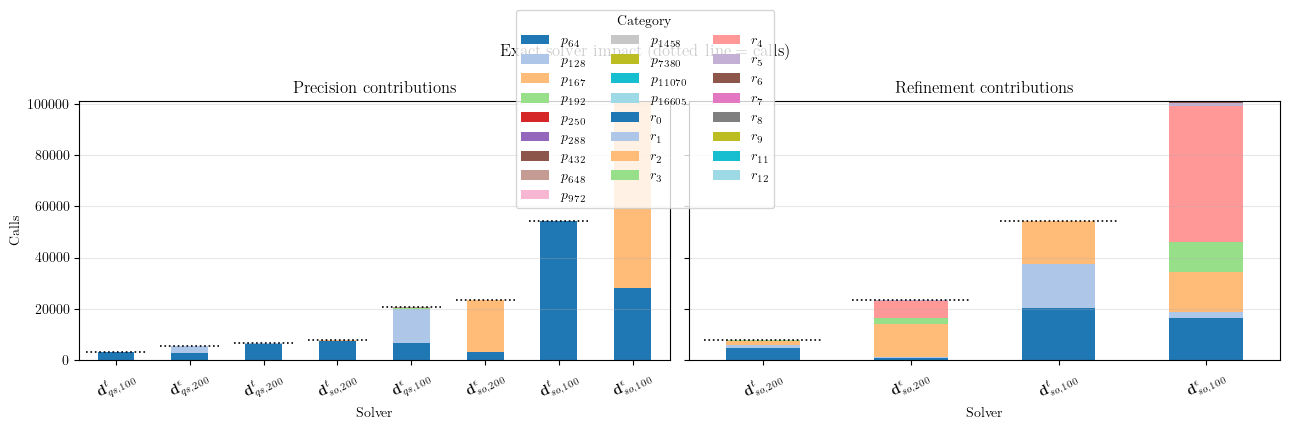

## Exact solver impact

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Calls | $p_{64}$ | $p_{128}$ | $p_{167}$ | $p_{192}$ | $p_{250}$ | $p_{288}$ | $p_{432}$ | $p_{648}$ | $p_{972}$ | $p_{1458}$ | $p_{7380}$ | $p_{11070}$ | $p_{16605}$ | $r_{0}$ | $r_{1}$ | $r_{2}$ | $r_{3}$ | $r_{4}$ | $r_{5}$ | $r_{6}$ | $r_{7}$ | $r_{8}$ | $r_{9}$ | $r_{11}$ | $r_{12}$ |
| ------ | ----- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\epsilon $ | 100961 | 27937 | | 73014 | | 10 | | | | | | | | | 16260 | 2332 | 15629 | 11744 | 53122 | 1148 | 459 | 169 | 94 | 3 | 1 | |
| $ \textbf{d}_{so,200}^\epsilon $ | 23288 | 3066 | | 20220 | | 2 | | | | | | | | | 811 | 276 | 12897 | 2444 | 6722 | 110 | 17 | 7 | 2 | 2 | | |
| $ \textbf{d}_{so,200}^t $ | 7782 | 7424 | | 353 | | 5 | | | | | | | | | 4651 | 1297 | 1559 | 111 | 86 | 61 | 2 | 9 | 4 | 1 | | 1 |
| $ \textbf{d}_{so,100}^t $ | 54240 | 54229 | | 11 | | | | | | | | | | | 20440 | 17235 | 16557 | 4 | 3 | 1 | | | | | | |
| $ \textbf{d}_{qs,100}^\epsilon $ | 20697 | 6570 | 13472 | | 216 | | 53 | 37 | 286 | 3 | 4 | 1 | 1 | 54 | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^\epsilon $ | 5477 | 2570 | 2726 | | 37 | | 29 | 5 | 102 | 1 | 1 | | 1 | 5 | | | | | | | | | | | | |
| $ \textbf{d}_{qs,100}^t $ | 3163 | 3077 | 83 | | 1 | | 2 | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^t $ | 6605 | 6377 | 228 | | | | | | | | | | | | | | | | | | | | | | | |


In [35]:
def exact_solver_impact(solvers_analysis: list[tuple[str, pd.DataFrame, str]]):
    # Instance difficulty categorization
    text = f"""## Exact solver impact

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Calls |"""
    precisions = set()
    refinements = set()

    solvers_analysis = [(solver_name, df[df[f"result{solver_id}"].isin(["sat", "unsat"])], solver_id) for solver_name, df, solver_id in solvers_analysis if "theory::arith::z::arith::relax::calls" in df.columns]

    data = {}

    for solver_name, df, solver_id in solvers_analysis:
        assert "theory::arith::z::arith::relax::calls" in df.columns
        assert df[f"result{solver_id}"].isin(["sat", "unsat"]).all()
        for col in df.columns:
            if col.startswith("precision_") and df[col].sum() > 0:
                precisions.add(col[len("precision_"):])
        for col in df.columns:
            if col.startswith("refinements_") and df[col].sum() > 0:
                refinements.add(col[len("refinements_"):])

    precisions = sorted(precisions, key=lambda x: int(x))
    refinements = sorted(refinements, key=lambda x: int(x))

    for precision in precisions:
        text += f" $p_{{{precision}}}$ |"
    for refinement in refinements:
        text += f" $r_{{{refinement}}}$ |"

    text += "\n| ------ | ----- |"

    for precision in precisions:
        text += f" {'-' * 3} |"
    for refinement in refinements:
        text += f" {'-' * 3} |"

    text += "\n"

    for solver_name, df, solver_id in solvers_analysis:

        calls = int(df["theory::arith::z::arith::relax::calls"].sum())

        # Consistency checks requested: present precision/refinement counters should sum to calls.
        precision_cols = [c for c in df.columns if c.startswith("precision_")]
        refinement_cols = [c for c in df.columns if c.startswith("refinements_")]

        if precision_cols:
            precision_sum = int(df[precision_cols].sum().sum())
            assert precision_sum == calls, (
                f"Precision totals do not match calls for {solver_name}: "
                f"precision_sum={precision_sum}, calls={calls}"
            )
        if refinement_cols:
            refinement_sum = int(df[refinement_cols].sum().sum())
            assert refinement_sum == calls, (
                f"Refinement totals do not match calls for {solver_name}: "
                f"refinement_sum={refinement_sum}, calls={calls}"
            )

        row = f"| {solver_name} | {calls} |"
        for precision in precisions:
            if f"precision_{precision}" in df.columns:
                row += f" {int(df[f'precision_{precision}'].sum())} |"
            else:
                row += " |"
        for refinement in refinements:
            if f"refinements_{refinement}" in df.columns:
                row += f" {int(df[f'refinements_{refinement}'].sum())} |"
            else:
                row += " |"
        data[solver_name] = {
            r"\# Calls": calls,
                **{f"$p_{{{precision}}}$": int(df[f"precision_{precision}"].sum()) for precision in precisions if f"precision_{precision}" in df.columns},
                **{f"$r_{{{refinement}}}$": int(df[f"refinements_{refinement}"].sum()) for refinement in refinements if f"refinements_{refinement}" in df.columns},
        }
        text += row + "\n"

    df = pd.DataFrame(data).T
    for col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

    # Keep a numeric copy for plotting before turning empty values into strings for LaTeX aesthetics.
    plot_df = df.copy()

    df_for_latex = df.copy()
    for col in df_for_latex.columns:
        df_for_latex[col] = df_for_latex[col].apply(lambda x: f"{x}" if x > 0 else "")

    df_for_latex[[r"\# Calls"] + [f"$p_{{{precision}}}$" for precision in precisions] + [f"$r_{{{refinement}}}$" for refinement in refinements]].T.to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_exact_solver_impact.tex",
        float_format="%.2f",
    )

    # Plot precision/refinement contributions and compare against calls with dotted markers.
    precision_plot_cols = [f"$p_{{{precision}}}$" for precision in precisions]
    refinement_plot_cols = [f"$r_{{{refinement}}}$" for refinement in refinements]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

    # Precision subplot.
    ax_p = axes[0]
    if precision_plot_cols:
        precision_df = plot_df[[r"\# Calls"] + precision_plot_cols].sort_values(by=r"\# Calls")
        # Show only bars with non-zero precision contribution.
        precision_df = precision_df[precision_df[precision_plot_cols].sum(axis=1) > 0]
        if len(precision_df) > 0:
            precision_df[precision_plot_cols].plot(
                kind="bar",
                stacked=True,
                colormap="tab20",
                ax=ax_p,
                legend=False,
            )
            bar_width = 0.8
            for i, calls in enumerate(precision_df[r"\# Calls"].astype(float).to_numpy()):
                ax_p.hlines(
                    y=calls,
                    xmin=i - bar_width / 2,
                    xmax=i + bar_width / 2,
                    colors="black",
                    linestyles="dotted",
                    linewidth=1.2,
                    zorder=5,
                )
        else:
            ax_p.text(0.5, 0.5, "No non-zero precision bars", ha="center", va="center", transform=ax_p.transAxes)
            ax_p.set_xticks([])
    else:
        ax_p.text(0.5, 0.5, "No precision columns", ha="center", va="center", transform=ax_p.transAxes)
        ax_p.set_xticks([])

    ax_p.set_title("Precision contributions")
    ax_p.set_xlabel("Solver")
    ax_p.set_ylabel("Calls")
    ax_p.grid(axis="y", alpha=0.3)
    ax_p.tick_params(axis="x", labelrotation=25)

    # Refinement subplot.
    ax_r = axes[1]
    if refinement_plot_cols:
        refinement_df = plot_df[[r"\# Calls"] + refinement_plot_cols].sort_values(by=r"\# Calls")
        # Show only bars with non-zero refinement contribution.
        refinement_df = refinement_df[refinement_df[refinement_plot_cols].sum(axis=1) > 0]
        if len(refinement_df) > 0:
            refinement_df[refinement_plot_cols].plot(
                kind="bar",
                stacked=True,
                colormap="tab20",
                ax=ax_r,
                legend=False,
            )
            bar_width = 0.8
            for i, calls in enumerate(refinement_df[r"\# Calls"].astype(float).to_numpy()):
                ax_r.hlines(
                    y=calls,
                    xmin=i - bar_width / 2,
                    xmax=i + bar_width / 2,
                    colors="black",
                    linestyles="dotted",
                    linewidth=1.2,
                    zorder=5,
                )
        else:
            ax_r.text(0.5, 0.5, "No non-zero refinement bars", ha="center", va="center", transform=ax_r.transAxes)
            ax_r.set_xticks([])
    else:
        ax_r.text(0.5, 0.5, "No refinement columns", ha="center", va="center", transform=ax_r.transAxes)
        ax_r.set_xticks([])

    ax_r.set_title("Refinement contributions")
    ax_r.set_xlabel("Solver")
    ax_r.grid(axis="y", alpha=0.3)
    ax_r.tick_params(axis="x", labelrotation=25)

    # Build a combined legend once.
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    if handles:
        by_label = dict(zip(labels, handles))
        fig.legend(by_label.values(), by_label.keys(), title="Category", ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.08))

    fig.suptitle("Exact solver impact (dotted line = calls)")
    plt.tight_layout()
    plt.show()

    return md(text)


exact_solver_impact(
    solvers_analysis=[
        (r"$ \textbf{d}_{so,100}^\epsilon $", soplex_i100, "S"),
        (r"$ \textbf{d}_{so,200}^\epsilon $", soplex_i200, "S"),
        (r"$ \textbf{d}_{so,200}^t $", soplex_i100_strict, "S"),
        (r"$ \textbf{d}_{so,100}^t $", soplex_i200_strict, "S"),
        (r"$ \textbf{d}_{qs,100}^\epsilon $", qsoptex_i100, "Q"),
        (r"$ \textbf{d}_{qs,200}^\epsilon $", qsoptex_i200, "Q"),
        (r"$ \textbf{d}_{qs,100}^t $", qsoptex_i100_strict, "Q"),
        (r"$ \textbf{d}_{qs,200}^t $", qsoptex_i200_strict, "Q"),
    ],
)

---

## Section 4: Time Distribution and Instance Difficulty Analysis

### 4.1 Performance Profile Analysis

The following performance profiles help visualize how well each solver variant performs across the entire benchmark set.

In [36]:
def print_difficulty_analysis(
    solvers_analysis: list[tuple[str, pd.DataFrame, str]], total_count: int, group_name = "all"
):
    # Instance difficulty categorization
    text = f"""## Difficulty analysis on {group_name}

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
"""

    # Categorize instances by time range
    def categorize_time(time_val):
        if time_val < 0.1:
            return "Very Fast (<0.1s)"
        elif time_val < 1:
            return "Fast (0.1-1s)"
        elif time_val < 10:
            return "Medium (1-10s)"
        elif time_val < 100:
            return "Hard (10-100s)"
        else:
            return "Very Hard (>100s)"

    # Analyze institution distribution for each solver

    rows = []
    data = {}

    categories = ["Very Fast (<0.1s)", "Fast (0.1-1s)", "Medium (1-10s)", "Hard (10-100s)", "Very Hard (>100s)"]
    latex_categories = ["$[0, 0.1)$s", "$[0.1, 1)$s", "$[1, 10)$s", "$[10, 100)$s", r"$[100, \infty)$s"]
    for solver_name, df, solver_id in solvers_analysis:
        df_copy = (
            df.copy()
            if "theory::arith::z::arith::relax::calls" not in df.columns
            else df[df["theory::arith::z::arith::relax::calls"] > 0].copy()
        )
        df_copy = df_copy[df_copy[f"result{solver_id}"].isin(["sat", "unsat"])]

        df_copy["category"] = df_copy[f"time{solver_id}"].apply(categorize_time)
        assert (
            len(df_copy["options::pivots"].unique()) == 1 if "options::pivots" in df_copy.columns else True
        ), f"Expected only one pivot limit per solver in the analysis, but got {df_copy['options::pivots'].unique()} on solver {solver_name}"
        pivot_limit = int(df_copy["options::pivots"].iloc[0]) if "options::pivots" in df_copy.columns else 0

        row = f"| {solver_name} | {'✔' if "options::strict" in df_copy.columns and  df_copy['options::strict'].iloc[0] else ''} | {pivot_limit}"

        data[solver_name] = {
            r"\# Sol. / \# Tot.": f"{len(df_copy)} / {total_count} ({100 * len(df_copy) / total_count:.1f}\\%)"
        }
        data[solver_name]["solved"] = len(df_copy)
        data[solver_name]["total"] = total_count

        for category, latex_category in zip(categories, latex_categories):
            count = (df_copy["category"] == category).sum()
            if count > 0:
                pct = 100 * count / len(df_copy)
                row += f" | {count} ({pct:.1f}%)"
                data[solver_name][latex_category] = int(count)
            else:
                row += " | 0"
        row += f" | {len(df_copy)} / {total_count} ({100 * len(df_copy) / total_count:.1f}%)"
        rows.append(row)

    data_df = pd.DataFrame(data).T
    for col in data_df.columns:
        if col != r"\# Sol. / \# Tot.":
            data_df[col] = data_df[col].fillna(0).astype(int)
    data_df.sort_values(by=["solved"] + latex_categories, inplace=True, ascending=False)
    data_df.drop(columns=["solved", "total"]).to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/difficulty_analysis_{group_name.lower().replace(' ', '_')}.tex",
        float_format="%.2f",
    )

    ax = data_df[latex_categories] .plot(
        kind="bar",
        stacked=True,
        colormap="tab20",
    )
    ax.set_ylabel("Solved instances")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=25, ha="center")
    plt.tight_layout()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height * 0.8])

    # Put a legend to the right of the current axis
    ax.legend(title="Category", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

    ax.figure.savefig(f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/difficulty_analysis_{group_name.lower().replace(' ', '_')}.pgf", bbox_inches="tight")

    return md(
        f"""{text}{"\n".join(rows)}
"""
    )

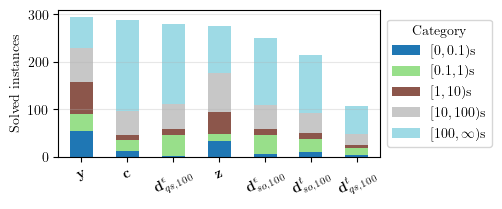

## Difficulty analysis on 100

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 55 (18.6%) | 35 (11.9%) | 68 (23.1%) | 72 (24.4%) | 65 (22.0%) | 295 / 319 (92.5%)
| $ \textbf{z} $ |  | 0 | 34 (12.3%) | 14 (5.1%) | 46 (16.7%) | 83 (30.1%) | 99 (35.9%) | 276 / 319 (86.5%)
| $ \textbf{c} $ |  | 0 | 12 (4.2%) | 24 (8.3%) | 10 (3.5%) | 50 (17.3%) | 193 (66.8%) | 289 / 319 (90.6%)
| $ \textbf{d}_{so,100}^\epsilon $ |  | 100 | 5 (2.0%) | 40 (16.0%) | 14 (5.6%) | 51 (20.4%) | 140 (56.0%) | 250 / 319 (78.4%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 11 (5.1%) | 27 (12.6%) | 12 (5.6%) | 43 (20.0%) | 122 (56.7%) | 215 / 319 (67.4%)
| $ \textbf{d}_{qs,100}^\epsilon $ |  | 100 | 2 (0.7%) | 43 (15.4%) | 13 (4.6%) | 54 (19.3%) | 168 (60.0%) | 280 / 319 (87.8%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 3 (2.8%) | 15 (13.9%) | 6 (5.6%) | 24 (22.2%) | 60 (55.6%) | 108 / 319 (33.9%)


In [37]:
print_difficulty_analysis(
    solvers_analysis=[
        (r"$ \textbf{y} $", in_100(yices), "Y"),
        (r"$ \textbf{z} $", in_100(z3), "Z"),
        (r"$ \textbf{c} $", in_100(cvc5), "C"),
        (r"$ \textbf{d}_{so,100}^\epsilon $", soplex_i100, "S"),
        (r"$ \textbf{d}_{so,100}^t $", soplex_i100_strict, "S"),
        (r"$ \textbf{d}_{qs,100}^\epsilon $", qsoptex_i100, "Q"),
        (r"$ \textbf{d}_{qs,100}^t $", qsoptex_i100_strict, "Q"),
    ],
    total_count= len(instances_100),
    group_name="100",
)

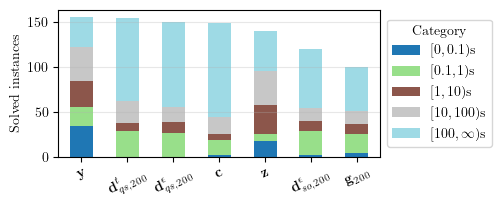

## Difficulty analysis on 200

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 34 (21.8%) | 22 (14.1%) | 28 (17.9%) | 38 (24.4%) | 34 (21.8%) | 156 / 177 (88.1%)
| $ \textbf{z} $ |  | 0 | 18 (12.9%) | 7 (5.0%) | 33 (23.6%) | 38 (27.1%) | 44 (31.4%) | 140 / 177 (79.1%)
| $ \textbf{c} $ |  | 0 | 2 (1.3%) | 17 (11.4%) | 6 (4.0%) | 19 (12.8%) | 105 (70.5%) | 149 / 177 (84.2%)
| $ \textbf{g}_{200}$ |  | 200 | 4 (4.0%) | 21 (21.0%) | 12 (12.0%) | 14 (14.0%) | 49 (49.0%) | 100 / 177 (56.5%)
| $ \textbf{d}_{so,200}^\epsilon $ |  | 200 | 2 (1.7%) | 27 (22.5%) | 11 (9.2%) | 14 (11.7%) | 66 (55.0%) | 120 / 177 (67.8%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 27 (17.9%) | 14 (9.3%) | 16 (10.6%) | 94 (62.3%) | 151 / 177 (85.3%)
| $ \textbf{d}_{qs,200}^\epsilon $ |  | 200 | 0 | 27 (18.0%) | 12 (8.0%) | 16 (10.7%) | 95 (63.3%) | 150 / 177 (84.7%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 29 (18.7%) | 9 (5.8%) | 24 (15.5%) | 93 (60.0%) | 155 / 177 (87.6%)


In [38]:
print_difficulty_analysis(
    solvers_analysis=[
        (r"$ \textbf{y} $", in_200(yices), "Y"),
        (r"$ \textbf{z} $", in_200(z3), "Z"),
        (r"$ \textbf{c} $", in_200(cvc5), "C"),
        (r"$ \textbf{g}_{200}$", in_200(glpk_200), "G"),
        (r"$ \textbf{d}_{so,200}^\epsilon $", soplex_i200, "S"),
        (r"$ \textbf{d}_{qs,200}^t $", soplex_i200_strict, "S"),
        (r"$ \textbf{d}_{qs,200}^\epsilon $", qsoptex_i200, "Q"),
        (r"$ \textbf{d}_{qs,200}^t $", qsoptex_i200_strict, "Q"),
    ],
   total_count= len(instances_200),
   group_name="200",
)

In [39]:
def print_difficulty_analysis_by_group(group: pd.DataFrame, iterations: int, group_name: str = "QF_LRA"):
    if iterations == 100:
        instances_filter = instances_100
        return print_difficulty_analysis(
            solvers_analysis=[
                (r"$ \textbf{y} $", in_instances(yices, group, instances_filter), "Y"),
                (r"$ \textbf{z} $", in_instances(z3, group, instances_filter), "Z"),
                (r"$ \textbf{c} $", in_instances(cvc5, group, instances_filter), "C"),
                (r"$ \textbf{d}_{so,100}^\epsilon $", in_instances(soplex_i100, group, instances_filter), "S"),
                (r"$ \textbf{d}_{so,100}^t $", in_instances(soplex_i100_strict, group, instances_filter), "S"),
                (r"$ \textbf{d}_{qs,100}^\epsilon $", in_instances(qsoptex_i100, group, instances_filter), "Q"),
                (r"$ \textbf{d}_{qs,100}^t $", in_instances(qsoptex_i100_strict, group, instances_filter), "Q"),
            ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        )
    elif iterations == 200:
        instances_filter = instances_200
        return print_difficulty_analysis(
            solvers_analysis=[
                (r"$ \textbf{y} $", in_instances(yices, group, instances_filter), "Y"),
                (r"$ \textbf{z} $", in_instances(z3, group, instances_filter), "Z"),
                (r"$ \textbf{c} $", in_instances(cvc5, group, instances_filter), "C"),
                (r"$ \textbf{g}_{200}$", in_instances(glpk_200, group, instances_filter), "G"),
                (r"$ \textbf{d}_{so,200}^\epsilon $", in_instances(soplex_i200, group, instances_filter), "S"),
                (r"$ \textbf{d}_{qs,100}^t $", in_instances(soplex_i200_strict, group, instances_filter), "S"),
                (r"$ \textbf{d}_{qs,200}^\epsilon $", in_instances(qsoptex_i200, group, instances_filter), "Q"),
                (r"$ \textbf{d}_{qs,200}^t $", in_instances(qsoptex_i200_strict, group, instances_filter), "Q"),
            ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        )

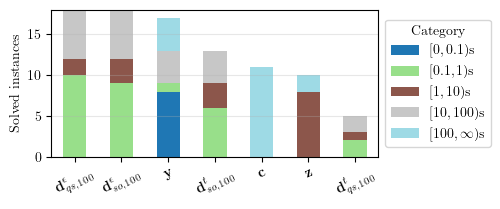

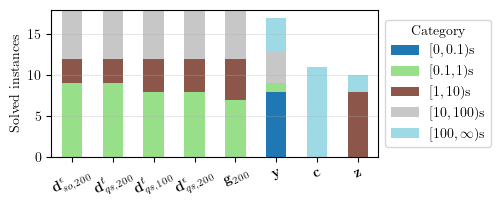

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [40]:
print_difficulty_analysis_by_group(lanteresse, 100, "Lanteresse"), print_difficulty_analysis_by_group(lanteresse, 200, "Lanteresse"),

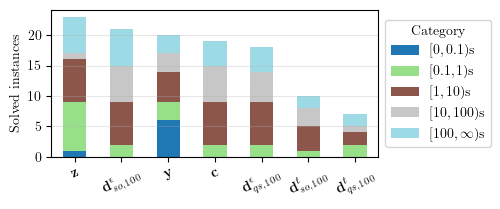

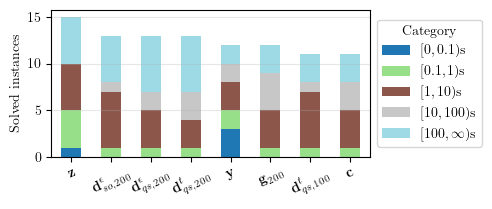

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [41]:
print_difficulty_analysis_by_group(mplib, 100, "MPLIB"), print_difficulty_analysis_by_group(mplib, 200, "MPLIB")


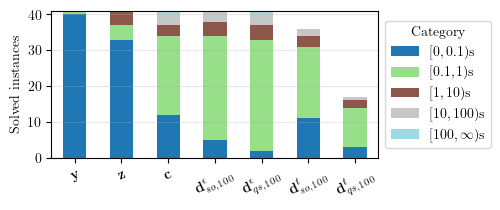

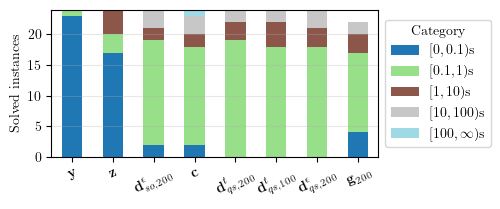

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [42]:
print_difficulty_analysis_by_group(dtp_scheduling, 100, "DTP Scheduling"), print_difficulty_analysis_by_group(dtp_scheduling, 200, "DTP Scheduling"),

In [43]:
glpk_200[glpk_200["options::pivots"] != 200]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,options::external-lp-solver,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,


In [44]:
z3_profile = z3.reset_index()[["file", "timeZ", "resultZ"]].set_index("file")
cvc5_profile = cvc5.reset_index()[["file", "timeC", "resultC"]].set_index("file")
yices_profile = yices.reset_index()[["file", "timeY", "resultY"]].set_index("file")
glpk_i200_profile = (
    glpk_200.reset_index()[["file", "timeG", "resultG", "options::pivots"]]
    .rename(columns={"timeG": "timeG200", "resultG": "resultG200"})
    .set_index("file")
)
soplex_i100_profile = (
    soplex_i100.reset_index()[["file", "timeS", "resultS", "options::pivots"]]
    .rename(columns={"timeS": "timeS100", "resultS": "resultS100"})
    .set_index("file")
)
soplex_i200_profile = (
    soplex_i200.reset_index()[["file", "timeS", "resultS", "options::pivots"]]
    .rename(columns={"timeS": "timeS200", "resultS": "resultS200"})
    .set_index("file")
)
soplex_i100_strict_profile = (
    soplex_i100_strict.reset_index()[["file", "timeS", "resultS", "options::pivots"]]
    .rename(columns={"timeS": "timeS100S", "resultS": "resultS100S"})
    .set_index("file")
)
soplex_i200_strict_profile = (
    soplex_i200_strict.reset_index()[["file", "timeS", "resultS", "options::pivots"]]
    .rename(columns={"timeS": "timeS200S", "resultS": "resultS200S"})
    .set_index("file")
)
qsoptex_i100_profile = (
    qsoptex_i100.reset_index()[["file", "timeQ", "resultQ", "options::pivots"]]
    .rename(columns={"timeQ": "timeQ100", "resultQ": "resultQ100"})
    .set_index("file")
)
qsoptex_i100_strict_profile = (
    qsoptex_i100_strict.reset_index()[["file", "timeQ", "resultQ", "options::pivots"]]
    .rename(columns={"timeQ": "timeQ100S", "resultQ": "resultQ100S"})
    .set_index("file")
)
qsoptex_i200_profile = (
    qsoptex_i200.reset_index()[["file", "timeQ", "resultQ", "options::pivots"]]
    .rename(columns={"timeQ": "timeQ200", "resultQ": "resultQ200"})
    .set_index("file")
)
qsoptex_i200_strict_profile = (
    qsoptex_i200_strict.reset_index()[["file", "timeQ", "resultQ", "options::pivots"]]
    .rename(columns={"timeQ": "timeQ200S", "resultQ": "resultQ200S"})
    .set_index("file")
)
# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_instances_100 = list(instances_100_list)
external_instances_200 = list(instances_200_list)
cvc5_variants_results = [
    SolverResult(cvc5_profile, r"$ \textbf{c} $", "C"),
    SolverResult(glpk_i200_profile, r"$ \textbf{g}_{200}$", "G200"),
    SolverResult(soplex_i100_profile, r"$ \textbf{d}_{so,100}^\epsilon $", "S100"),
    SolverResult(soplex_i200_profile, r"$ \textbf{d}_{so,200}^\epsilon $", "S200"),
    SolverResult(soplex_i100_strict_profile, r"$ \textbf{d}_{so,100}^t $", "S100S"),
    SolverResult(soplex_i200_strict_profile, r"$ \textbf{d}_{so,200}^t $", "S200S"),
    SolverResult(qsoptex_i100_profile, r"$ \textbf{d}_{qs,100}^\epsilon $", "Q100"),
    SolverResult(qsoptex_i100_strict_profile, r"$ \textbf{d}_{qs,100}^t $", "Q100S"),
    SolverResult(qsoptex_i200_profile, r"$ \textbf{d}_{qs,200}^\epsilon $", "Q200"),
    SolverResult(qsoptex_i200_strict_profile, r"$ \textbf{d}_{qs,200}^t $", "Q200S"),
]
other_profile_results = (
    SolverResult(z3_profile, r"$ \textbf{z} $", "Z"),
    SolverResult(yices_profile, r"$ \textbf{y} $", "Y"),
)


external_100_cvc5_variants_results = [
    result.replace_df(in_100(result.dataframe.drop(columns=["options::pivots"], errors="ignore")))
    for result in cvc5_variants_results
    if "options::pivots" not in result.dataframe.columns or result.dataframe["options::pivots"].iloc[0] == 100
]
external_100_profile_results = external_100_cvc5_variants_results + [result.replace_df(in_100(result.dataframe)) for result in other_profile_results]

external_200_cvc5_variants_results = [
    result.replace_df(in_200(result.dataframe.drop(columns=["options::pivots"], errors="ignore")))
    for result in cvc5_variants_results
    if "options::pivots" not in result.dataframe.columns or result.dataframe["options::pivots"].iloc[0] == 200
]
external_200_profile_results = external_200_cvc5_variants_results + [result.replace_df(in_200(result.dataframe)) for result in other_profile_results]

# for results in cvc5_variants_results:
#     if results.solver_id not in ("C", "G"):
#         integrate_cvc5(results, glpk_200_profile, instances_n100 if results.solver_id in ("S100", "Q100", "S100S", "Q100S") else instances_n200)
# for results in external_100_cvc5_variants_results:
#     if results.solver_id not in ("C", "G"):
#         integrate_cvc5(results, glpk_profile.loc[np.intersect1d(glpk_profile.index, external_instances_100)], instances_n100 if results.solver_id in ("S100", "Q100", "S100S", "Q100S") else instances_n200)

In [45]:
column_map = {
    "timeY": r"$\textbf{y}$",
    "timeZ": r"$\textbf{z}$",
    "timeC": r"$\textbf{c}$",
    "timeG200": r"$\textbf{g}_{gs,200}$",
    "timeS100": r"$\textbf{d}_{so,100}^\epsilon$",
    "timeS100S": r"$\textbf{d}_{so,100}^t$",
    "timeS200": r"$\textbf{d}_{so,200}^\epsilon$",
    "timeS200S": r"$\textbf{d}_{so,200}^t$",
    "timeQ100": r"$\textbf{d}_{qs,100}^\epsilon$",
    "timeQ100S": r"$\textbf{d}_{qs,100S}^t$",
    "timeQ200": r"$\textbf{d}_{qs,200}^\epsilon$",
    "timeQ200S": r"$\textbf{d}_{qs,200}^t$",
}

In [46]:
df_all_100 = reduce(
    lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how="outer"), (result.dataframe for result in external_100_profile_results)
)
column_map_100 = {col: name for col, name in column_map.items() if col in df_all_100.columns}
df_all_100["Problem"] = df_all_100.index
df_all_100["Problem"] = df_all_100["Problem"].apply(lambda x: x.replace(".smt2", "")[:30])
df_all_100[["Problem"] + list(column_map_100.keys())].rename(columns=column_map_100).to_latex(
    f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/all_times_100.tex",
    float_format="%.1f",
    longtable=True,
    index=False,
    na_rep="-",
)
df_all_100

,timeC,resultC,timeS100,resultS100,timeS100S,resultS100S,timeQ100,resultQ100,timeQ100S,resultQ100S,timeZ,resultZ,timeY,resultY,Problem
file,,,,,,,,,,,,,,,
0067-labyrinth-18-0.smt2,150.865,sat,103.000,sat,129.842,sat,176.731,sat,NaN,NaN,16.25,sat,4.178,sat,0067-labyrinth-18-0
0150-labyrinth-16-0.smt2,1951.259,sat,787.892,sat,463.212,sat,349.843,sat,NaN,NaN,403.26,sat,1626.954,sat,0150-labyrinth-16-0
0159-labyrinth-20-0.smt2,433.273,sat,498.538,sat,371.624,sat,431.836,sat,NaN,NaN,36.52,sat,81.029,sat,0159-labyrinth-20-0
0198-labyrinth-19-0.smt2,564.470,sat,601.846,sat,1982.024,sat,1290.821,sat,NaN,NaN,241.09,sat,875.248,sat,0198-labyrinth-19-0
0206-labyrinth-20-0.smt2,NaN,NaN,2757.048,sat,NaN,NaN,NaN,NaN,NaN,NaN,6910.05,sat,20863.141,unknown,0206-labyrinth-20-0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2,51.103,unsat,NaN,NaN,113.521,unsat,2274.364,unsat,499.814,unsat,6.11,unsat,13.632,unsat,yPositive-SIscaled75.bpl_Itera
yPositive-SIscaled75.bpl_Iteration1_Loop_4-phaseTemplate.smt2,27.698,sat,9471.127,sat,NaN,NaN,16.413,sat,NaN,NaN,1.40,sat,3.288,sat,yPositive-SIscaled75.bpl_Itera
yPositive-SIscaled75.bpl_Iteration1_Loop_4-pieceTemplate.smt2,197.708,unsat,NaN,NaN,1705.928,unsat,1395.241,unsat,1832.885,unsat,58.18,unsat,39.522,unsat,yPositive-SIscaled75.bpl_Itera


In [47]:
df_all_200 = reduce(
    lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how="outer"), (result.dataframe for result in external_200_profile_results)
)
column_map_200 = {col: name for col, name in column_map.items() if col in df_all_200.columns}
df_all_200["Problem"] = df_all_200.index
df_all_200["Problem"] = df_all_200["Problem"].apply(lambda x: x.replace(".smt2", "")[:30])
df_all_200[["Problem"] + list(column_map_200.keys())].rename(columns=column_map_200).to_latex(
    f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/all_times_200.tex",
    float_format="%.1f",
    longtable=True,
    index=False,
    na_rep="-",
)
df_all_200

,timeC,resultC,timeG200,resultG200,timeS200,resultS200,timeS200S,resultS200S,timeQ200,resultQ200,timeQ200S,resultQ200S,timeZ,resultZ,timeY,resultY,Problem
file,,,,,,,,,,,,,,,,,
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,9545.182,unsat,3891.613,unsat,2642.541,unsat,936.264,unsat,3364.834,unsat,1427.572,unsat,1742.74,unsat,20920.894,unknown,BradleyMannaSipma-2005ICALP-Fi
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_7-phaseTemplate.smt2,2084.945,unsat,635.487,unsat,1375.912,unsat,611.943,unsat,1240.908,unsat,1439.975,unsat,20904.41,timeout,20885.887,unknown,Braverman-2006CAV-Ex1-int.bpl_
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,1334.584,unsat,638.343,unsat,1379.677,unsat,540.193,unsat,1106.269,unsat,1715.667,unsat,20920.90,timeout,20884.814,unknown,Braverman-2006CAV-Ex1-int.bpl_
Collatz.bpl_Iteration1_Loop_7-phaseTemplate.smt2,4398.008,unsat,NaN,NaN,2136.499,unsat,1203.953,unsat,1935.930,unsat,1419.781,unsat,82.63,unsat,5.304,unsat,Collatz.bpl_Iteration1_Loop_7-
GcdNew.bpl_Iteration1_Lasso_7-phaseTemplate.smt2,1440.725,sat,1051.326,sat,1129.917,sat,1000.586,sat,1303.659,sat,1174.316,sat,110.78,sat,21.613,sat,GcdNew.bpl_Iteration1_Lasso_7-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2,51.103,unsat,21000.549,unknown,21000.420,unknown,264.210,unsat,199.102,unsat,169.766,unsat,6.11,unsat,13.632,unsat,yPositive-SIscaled75.bpl_Itera
yPositive-SIscaled75.bpl_Iteration1_Loop_4-phaseTemplate.smt2,27.698,sat,33.318,sat,12.153,sat,15.135,sat,9.236,sat,25.271,sat,1.40,sat,3.288,sat,yPositive-SIscaled75.bpl_Itera
yPositive-SIscaled75.bpl_Iteration1_Loop_4-pieceTemplate.smt2,197.708,unsat,NaN,NaN,NaN,NaN,250.138,unsat,177.766,unsat,360.549,unsat,58.18,unsat,39.522,unsat,yPositive-SIscaled75.bpl_Itera


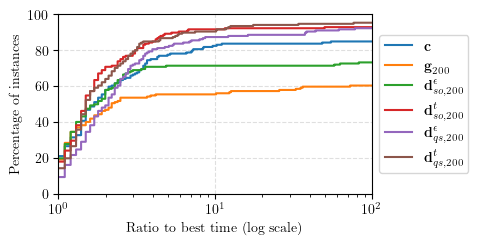

In [48]:
ax, fig = plot_performance_profiles(
    *external_200_cvc5_variants_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=100,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_cvc5.pgf", dpi=300)

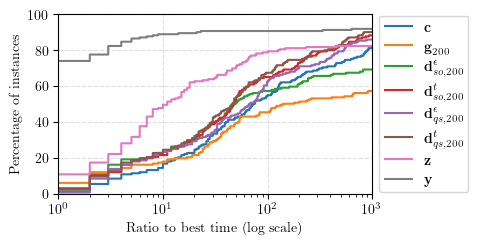

In [49]:
ax, fig = plot_performance_profiles(
    *external_200_profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_all.pgf", dpi=300)

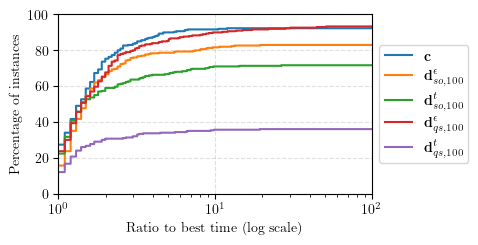

In [50]:
ax, fig = plot_performance_profiles(
    *external_100_cvc5_variants_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=100,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_cvc5.pgf", dpi=300)

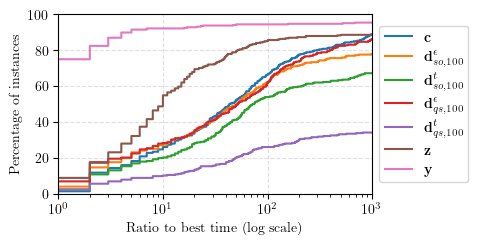

In [51]:
ax, fig = plot_performance_profiles(
    *external_100_profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_all.pgf", dpi=300)